In [1]:
%run /home/mrixen/Case_studies/Clean_code/functions/functions.ipynb

### Load Data

In [2]:
start_era = '2020-06-05T00'
end_era = '2020-06-12T00'
ds_era_geo = load_era5_dataset_series_dask(
    start=start_era,
    end=end_era,
    base_path='/net/thermo/atmosdyn/era5/cdf',
    file_prefix='H',
)
ds_era_Z= load_era5_dataset_series_dask(
    start=start_era,
    end=end_era,
    base_path='/net/thermo/atmosdyn/era5/cdf',
    file_prefix='Z',
)

In [3]:
ds_IFS_ens = xr.open_dataset("/highres_nobackup/mrixen/ifs_ens/MARS/MARS_request_ens/June/eps_20200605_00.nc")
ds_IFS_ens = ds_IFS_ens.rename({'latitude': 'lat', 'longitude': 'lon'})
ds_IFS_ens = ds_IFS_ens.sel(lat=ds_IFS_ens.lat[::-1])

ds_IFS = xr.open_dataset('/highres_nobackup/michaesp/eps.ecmwf/cfc_20200605_00.nc')
ds_IFS = ds_IFS.rename({'latitude': 'lat', 'longitude': 'lon'})
ds_IFS = ds_IFS.sel(lat=ds_IFS.lat[::-1])

ERA5_30D_mean_climatology = xr.open_dataset('/home/mrixen/Case_studies/Clean_code/data/3D_running_mean_era5_Z500_2_shifted_times_to_25.nc')['Z'].isel(plev=0).sel(lat=slice(20,80), lon = slice(-100,45))/9.81
z500_era = ds_era_geo.Z.sel(plev=50000).sel(lat=slice(20,80), lon = slice(-100,45))  /9.81

In [4]:
base_path = "/highres_nobackup/mrixen/simulations/June"

# === Define resolutions and folder names ===
resolutions = {
    "R02B06": "R02B06/Ensembles",
    "R02B07": "R02B07/Ensembles",
    "R02B08": "R02B08/Ensembles",
    "R02B08_no_conv": "R02B08_no_conv/Ensembles",
    "R02B09": "R02B09/Ensembles",
    "R02B10": "R02B10/Ensembles"
}

# === Container for all datasets ===
ds_dict = {}

# === Loop through resolutions ===
for res, subdir in resolutions.items():
    path = f"{base_path}/{subdir}"

    # 1️⃣ Find all matching ensemble files
    files = sorted(glob.glob(f"{path}/June_ensemble_{res}_IC_???_out6_concat_ERA.nc"))
    if not files:
        print(f"⚠️ No files found for {res}")
        continue

    # 2️⃣ Extract ensemble IDs
    ensemble_ids = [int(re.search(r'_IC_(\d+)_', f).group(1)) for f in files]

    # 3️⃣ Open lazily and in parallel
    print(f"📂 Opening {len(files)} files for {res} ...")
    ds = xr.open_mfdataset(
        files,
        concat_dim="ensemble",
        combine="nested",
        parallel=True,
        engine="netcdf4",
        chunks={"time": 50}
    )

    # 4️⃣ Assign ensemble coordinate
    ds = ds.assign_coords(ensemble=("ensemble", ensemble_ids))

    # 5️⃣ Store dataset in dictionary
    ds_dict[res] = ds
    print(f"✅ Loaded {res} with shape {dict(ds.dims)}")

# === Example access ===
ds_R02B06 = ds_dict["R02B06"]
ds_R02B07 = ds_dict["R02B07"]
ds_R02B08 = ds_dict["R02B08"]
ds_R02B08_no_conv = ds_dict["R02B08_no_conv"]
ds_R02B09 = ds_dict["R02B09"]
ds_R02B10 = ds_dict["R02B10"]

📂 Opening 50 files for R02B06 ...
✅ Loaded R02B06 with shape {'ensemble': 50, 'time': 57, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 50 files for R02B07 ...
✅ Loaded R02B07 with shape {'ensemble': 50, 'time': 57, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 20 files for R02B08 ...
✅ Loaded R02B08 with shape {'ensemble': 20, 'time': 57, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 20 files for R02B08_no_conv ...
✅ Loaded R02B08_no_conv with shape {'ensemble': 20, 'time': 57, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 10 files for R02B09 ...
✅ Loaded R02B09 with shape {'ensemble': 10, 'time': 57, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 3 files for R02B10 ...
✅ Loaded R02B10 with shape {'ensemble': 3, 'time': 57, 'plev': 37, 'lat': 361, 'lon': 720}


## ACC evaluation

In [5]:
def compute_acc_rmse(ds_forecast, ds_analysis, ERA5_30D_mean_climatology):
    """
    Compute the anomaly correlation coefficient (ACC) between two datasets.
    
    Parameters:
        ds_forecast (xarray.DataArray): DataArray for IFS data
        ds_analysis (xarray.DataArray): DataArray for ERA data
    
    Returns:
        xarray.DataArray: Anomaly correlation coefficient over time
    """
    ds_forecast = ds_forecast.sel(lat=slice(35, 75), lon=slice(-75, 0))
    ds_analysis = ds_analysis.sel(lat=slice(35, 75), lon=slice(-75, 0))
    ERA5_30D_mean_climatology = ERA5_30D_mean_climatology.sel(lat=slice(35, 75), lon=slice(-75, 0))

    times_era = ERA5_30D_mean_climatology.time.values
    times_fc  = ds_forecast.time.values
    times_an  = ds_analysis.time.values

    common_times = np.intersect1d(np.intersect1d(times_era, times_fc), times_an)
    # Step 3: Subset each dataset to those common times
    ERA5_30D_mean_climatology_subset = ERA5_30D_mean_climatology.sel(time=common_times)
    ds_forecast_subset = ds_forecast.sel(time=common_times)
    ds_analysis_subset = ds_analysis.sel(time=common_times)

    f_anom = (ds_forecast_subset - ERA5_30D_mean_climatology_subset)
    a_anom = (ds_analysis_subset - ERA5_30D_mean_climatology_subset)

    f_anom_avg = f_anom.mean(dim=['lat', 'lon'])
    a_anom_avg = a_anom.mean(dim=['lat', 'lon'])

    numerator = ((f_anom - f_anom_avg) * (a_anom - a_anom_avg)).sum(dim=['lat', 'lon'])

    denominator = (
        (((f_anom - f_anom_avg))**2).sum(dim=['lat', 'lon']) *
        (((a_anom - a_anom_avg))**2).sum(dim=['lat', 'lon']))**0.5

    acc = numerator / denominator

    #add the computation of RMSE
    rmse_time = xs.rmse(ds_forecast_subset.chunk({'time': -1}), ds_analysis_subset.chunk({'time': -1}), dim=['lat', 'lon'], skipna=True) 
    
    return acc, rmse_time


In [6]:
# --- Define ensembles and plotting positions --- 
ensembles = {
    "R02B06": 
        { "path": "/highres_nobackup/mrixen/simulations/June/R02B06/Ensembles/June_ensemble_R02B06_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-07T23:30"), 
        "color": "purple" }, 

    "R02B07": 
        { "path": "/highres_nobackup/mrixen/simulations/June/R02B07/Ensembles/June_ensemble_R02B07_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-07T23:30"), 
         "color": "darkorange" }, 
    "R02B08": 
        { "path": "/highres_nobackup/mrixen/simulations/June/R02B08/Ensembles/June_ensemble_R02B08_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-07T22:30"), 
         "color": "forestgreen" },

    "R02B08 conv. off": 
        { "path": "/highres_nobackup/mrixen/simulations/June/R02B08_no_conv/Ensembles/June_ensemble_R02B08_no_conv_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-07T22:25"), 
         "color": "#8da0cb" },
    "R02B09": 
        { "path": "/highres_nobackup/mrixen/simulations/June/R02B09/Ensembles/June_ensemble_R02B09_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-08T00:00"), 
         "color": "mediumblue" },
    "R02B10":
        { "path": "/highres_nobackup/mrixen/simulations/June/R02B10/Ensembles/June_ensemble_R02B10_IC_*_out6_concat_ERA.nc", 
         "time": pd.to_datetime("2020-02-08T01:30"), 
         "color": "firebrick" }
}


In [7]:
names_r02b06, acc_r02b06, rmse_r02b06 = compute_acc_members(
    ensembles["R02B06"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)
names_r02b07, acc_r02b07, rmse_r02b07 = compute_acc_members(
    ensembles["R02B07"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)
names_r02b08, acc_r02b08, rmse_r02b08 = compute_acc_members(
    ensembles["R02B08"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)
names_r02b08_no_conv, acc_r02b08_no_conv, rmse_r02b08_no_conv = compute_acc_members(
    ensembles["R02B08 conv. off"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)
names_r02b09, acc_r02b09, rmse_r02b09 = compute_acc_members(
    ensembles["R02B09"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)

names_r02b10, acc_r02b10, rmse_r02b10 = compute_acc_members(
    ensembles["R02B10"]["path"], z500_era, ERA5_30D_mean_climatology, return_rmse=True
)

rmse_dict = {
    "R02B06": rmse_r02b06,
    "R02B07": rmse_r02b07,
    "R02B08": rmse_r02b08,
    "R02B08_no_conv": rmse_r02b08_no_conv,
    "R02B09": rmse_r02b09,
    "R02B10": rmse_r02b10,
}

acc_dict = {
    "R02B06": acc_r02b06,
    "R02B07": acc_r02b07,
    "R02B08": acc_r02b08,
    "R02B08_no_conv": acc_r02b08_no_conv,
    "R02B09": acc_r02b09,
    "R02B10": acc_r02b10,
}

In [8]:
z500_ifs_ens = ds_IFS_ens.z.sel(level=500).sel(lat=slice(20,80), lon = slice(-100,45)).sel(time=slice("2020-06-05T00","2020-06-12T00")) /9.81
acc_ifs_ens, rmse_ifs_ens = compute_acc_rmse(z500_ifs_ens, z500_era, ERA5_30D_mean_climatology)
acc_ifs_ens = acc_ifs_ens.sel(time='2020-06-11T00:00:00.000000000')
rmse_ifs_ens = rmse_ifs_ens.sel(time='2020-06-11T00:00:00.000000000')

names_ifs = [
    f"Blocking_ensemble_IFS_IC_{i:03d}_out6_concat_ERA.nc"
    for i in range(1, 51)
]

In [9]:
ds_IFS = xr.open_dataset('/highres_nobackup/michaesp/eps.ecmwf/cfc_20200605_00.nc')
ds_IFS = ds_IFS.rename({'latitude': 'lat', 'longitude': 'lon'})
ds_IFS = ds_IFS.sel(lat=ds_IFS.lat[::-1])
z500_ifs = ds_IFS.z.sel(level=500).sel(lat=slice(20,80), lon = slice(-100,45)).sel(time=slice("2020-06-05T00","2020-06-11T12")) /9.81
acc_ifs, rmse_ifs = compute_acc_rmse(z500_ifs, z500_era, ERA5_30D_mean_climatology)
acc_ifs = acc_ifs.sel(time='2020-06-11T00:00:00.000000000')

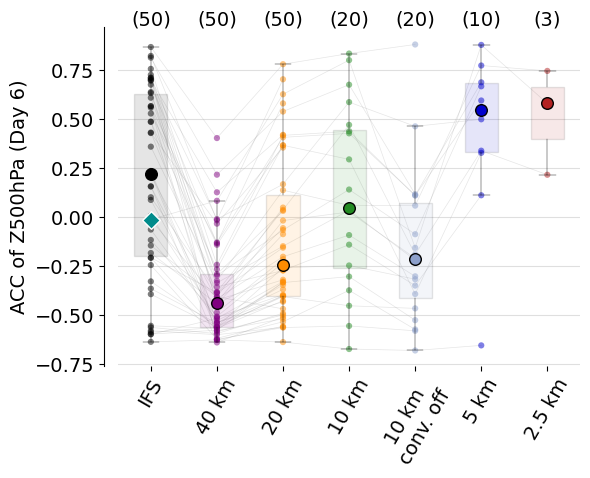

In [10]:
# --- Your datasets ---
datasets = {
    "IFS": {"names": names_ifs, "acc": acc_ifs_ens.values, "color": "black", "marker": "x"},
    "40 km": {"names": names_r02b06, "acc": acc_r02b06, "color": "purple", "marker": "o"},
    "20 km": {"names": names_r02b07, "acc": acc_r02b07, "color": "darkorange", "marker": "o"},
    "10 km": {"names": names_r02b08, "acc": acc_r02b08, "color": "forestgreen", "marker": "o"},
    "10 km\nconv. off": {"names": names_r02b08_no_conv, "acc": acc_r02b08_no_conv, "color": "#8da0cb", "marker": "o"},
    "5 km": {"names": names_r02b09, "acc": acc_r02b09, "color": "mediumblue", "marker": "o"},
    "2.5 km": {"names": names_r02b10, "acc": acc_r02b10, "color": "firebrick", "marker": "o"},
}

# Prepare single panel
fig, ax2 = plt.subplots(
    1, 1,
    figsize=(6, 5),
    subplot_kw=None
)

dataset_names = list(datasets.keys())

# --- Collect ensemble IDs for optional linking ---
ensemble_ids = sorted({
    int(re.search(r"_IC_(\d{3})_", f).group(1))
    for cfg in datasets.values()
    for f in cfg["names"]
})


# ======================================================
# RIGHT PANEL — Mean ACC + scatter + boxplots
# ======================================================

# --- 1️⃣ Scatter points per dataset ---
for i, (name, cfg) in enumerate(datasets.items()):
    acc = np.array(cfg["acc"])
    acc = acc[np.isfinite(acc)]
    if len(acc) == 0:
        continue

    ax2.scatter(
        np.full(len(acc), i), acc,
        color=cfg["color"],
        s=20,
        alpha=0.5,
        edgecolor="none",
        zorder=2
    )

for ens_id in ensemble_ids:
    x_vals, y_vals = [], []
    for i, (name, cfg) in enumerate(datasets.items()):
        idx = [j for j, f in enumerate(cfg["names"]) if f"_IC_{ens_id:03d}_" in f]
        if len(idx) == 1:
            acc_val = cfg["acc"][idx[0]]
            if np.isfinite(acc_val):
                x_vals.append(i)
                y_vals.append(acc_val)

    if len(x_vals) >= 2:
        ax2.plot(x_vals, y_vals, color="gray", alpha=0.2, linewidth=0.5, zorder=1)


# --- 2️⃣ Boxplots underneath scatter points ---
box_data = [
    np.array(cfg["acc"])[np.isfinite(cfg["acc"])]
    for cfg in datasets.values()
]

box = ax2.boxplot(
    box_data,
    positions=np.arange(len(dataset_names)),
    widths=0.5,
    patch_artist=True,
    boxprops=dict(facecolor="white", color="k", alpha=0),
    medianprops=dict(color="k", linewidth=1.2, alpha=0),
    whiskerprops=dict(color="k", linewidth=0.3),
    capprops=dict(color="k", linewidth=0.3),
    flierprops=dict(marker="o", color="k", markersize=3, alpha=0)
)

# Color boxes according to dataset
for patch, (name, cfg) in zip(box['boxes'], datasets.items()):
    patch.set_facecolor(cfg["color"])
    patch.set_alpha(0.1)


# --- 3️⃣ Overlay median points ---
for i, (name, cfg) in enumerate(datasets.items()):
    acc = np.array(cfg["acc"])
    acc = acc[np.isfinite(acc)]
    if len(acc) == 0:
        continue
    median_val = np.nanmedian(acc)
    ax2.scatter(i, median_val, color=cfg["color"], s=70, edgecolor="k", zorder=3)

ifs_acc_value = acc_ifs  # your scalar ACC for IFS
ax2.scatter(
    0,               # IFS is the first dataset
    ifs_acc_value,   # ACC value
    color="darkcyan",
    s=80,           # larger marker to stand out
    marker="D",      # diamond
    edgecolor="white",
    zorder=4,
    label="IFS ACC"
)

sample_sizes = [50, 50, 50, 20, 20, 10, 3]

# Determine y position slightly above current data range
y_top = ax2.get_ylim()[1]

for i, n in enumerate(sample_sizes):
    ax2.text(
        i,
        y_top + 0.002,   # small offset above plot
        f"({n})",
        ha="center",
        va="bottom",
        fontsize=14
    )

# Extend ylim slightly so numbers are visible
ax2.set_ylim(ax2.get_ylim()[0], y_top + 0.01)


# --- 4️⃣ Formatting ---
ax2.set_xticks(range(len(dataset_names)))
ax2.set_xticklabels(dataset_names, rotation=60)
ax2.set_ylabel("ACC of Z500hPa (Day 6)")
ax2.spines["top"].set_visible(False)
ax2.spines["bottom"].set_visible(False)

ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_position(("outward", 10))

ax2.grid(True, axis="y", alpha=0.4)
ax2.set_xlim(-0.5, len(dataset_names) - 0.5)

plt.tight_layout()
plt.savefig("../Figures/June_ACC_single_IFS_ICON.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# Parameters
n_boot = 10000  # number of bootstrap samples
ci = 95         # confidence interval
datasets_keys = list(datasets.keys())

# Function: bootstrap CI for paired differences
def bootstrap_ci_paired(x, y, n_boot=10000, ci=95):
    delta = np.array(x) - np.array(y)
    boot_means = []
    for _ in range(n_boot):
        idx = np.random.choice(len(delta), size=len(delta), replace=True)
        boot_means.append(np.mean(delta[idx]))
    lower = np.percentile(boot_means, (100 - ci)/2)
    upper = np.percentile(boot_means, 100 - (100 - ci)/2)
    p_value = np.mean(np.array(boot_means) <= 0)  # one-sided: delta>0
    return np.mean(delta), lower, upper, p_value

# Store results
results = []

# Pairwise comparisons
for i, name1 in enumerate(datasets_keys):
    acc1 = np.asarray(datasets[name1]["acc"]).astype(float).ravel()
    for j, name2 in enumerate(datasets_keys):
        if i >= j:
            continue  # avoid duplicates and self-comparison
        acc2 = np.asarray(datasets[name2]["acc"]).astype(float).ravel()

        # Truncate to common members (nested ensembles)
        n = min(len(acc1), len(acc2))
        a1 = acc1[:n]
        a2 = acc2[:n]

        # Remove NaNs
        mask = ~np.isnan(a1) & ~np.isnan(a2)
        a1 = a1[mask]
        a2 = a2[mask]

        if len(a1) == 0:
            continue

        mean_delta, lower, upper, p_val = bootstrap_ci_paired(a2, a1, n_boot=n_boot, ci=ci)

        results.append({
            "pair": f"{name2} - {name1}",
            "n_pairs": len(a1),
            "mean_delta": mean_delta,
            "ci_lower": lower,
            "ci_upper": upper,
            "p_value": p_val
        })

# Print results
for r in results:
    print(r)

{'pair': '40 km - IFS', 'n_pairs': 50, 'mean_delta': np.float64(-0.5632544736437727), 'ci_lower': np.float64(-0.6684466165262766), 'ci_upper': np.float64(-0.4576025487077332), 'p_value': np.float64(1.0)}
{'pair': '20 km - IFS', 'n_pairs': 50, 'mean_delta': np.float64(-0.3016385982990492), 'ci_lower': np.float64(-0.40800256127765017), 'ci_upper': np.float64(-0.1994625361587104), 'p_value': np.float64(1.0)}
{'pair': '10 km - IFS', 'n_pairs': 20, 'mean_delta': np.float64(-0.21487034474618083), 'ci_lower': np.float64(-0.3836757411415519), 'ci_upper': np.float64(-0.03637580535680051), 'p_value': np.float64(0.991)}
{'pair': '10 km\nconv. off - IFS', 'n_pairs': 20, 'mean_delta': np.float64(-0.47771246562830455), 'ci_lower': np.float64(-0.6308493512924459), 'ci_upper': np.float64(-0.3280786191921776), 'p_value': np.float64(1.0)}
{'pair': '5 km - IFS', 'n_pairs': 10, 'mean_delta': np.float64(0.025975777408443014), 'ci_lower': np.float64(-0.1879715268733618), 'ci_upper': np.float64(0.26968484184

## MCS

In [19]:
lat_min_MCS = 40
lat_max_MCS = 60
lon_min_MCS = -110
lon_max_MCS = -65
time_pv = '2020-06-08T18:00'

In [20]:
def compute_all_ensembles(ds, threshold_pv):
    """
    Apply compute_MCS_intensity_pv to every ensemble member
    in a dataset that has an 'ensemble' dimension.

    Returns a NumPy array of shape (n_ensemble,)
    """
    ens_values = ds.ensemble.values
    results = []

    for e in ens_values:
        area = compute_MCS_intensity_pv(
            ds.sel(ensemble=e),
            threshold_pv,
            lat_min_MCS, lat_max_MCS, lon_min_MCS, lon_max_MCS
        )
        results.append(area)

    return np.array(results)

In [21]:
MCS_area_pv = {}  # container for results

time_pv = "2020-06-08T15:00"
threshold_pv = 0

for res, ds in ds_dict.items():
    print(f"➡️ Computing MCS PV area for {res} ...")
    
    MCS_area_pv[res] = compute_all_ensembles(
        ds.pv.sel(time=time_pv, plev=25000)/1e-6,
        threshold_pv=threshold_pv,
    )
    
    print(f"✔ Done: shape = {MCS_area_pv[res].shape}")

➡️ Computing MCS PV area for R02B06 ...
✔ Done: shape = (50,)
➡️ Computing MCS PV area for R02B07 ...
✔ Done: shape = (50,)
➡️ Computing MCS PV area for R02B08 ...
✔ Done: shape = (20,)
➡️ Computing MCS PV area for R02B08_no_conv ...
✔ Done: shape = (20,)
➡️ Computing MCS PV area for R02B09 ...
✔ Done: shape = (10,)
➡️ Computing MCS PV area for R02B10 ...
✔ Done: shape = (3,)


In [22]:
#computation of negative PV anomaly area for ERA
pv_era_250_MCS_US = xr.open_dataset('/highres_nobackup/mrixen/simulations/June/ERA_data/ERA_PV250_3H_2020060500_2020061200')
era5_area_MCS = compute_MCS_intensity_pv(pv_era_250_MCS_US.PV.sel(time=15, lev=250), threshold_pv, lat_min_MCS, lat_max_MCS, lon_min_MCS, lon_max_MCS)

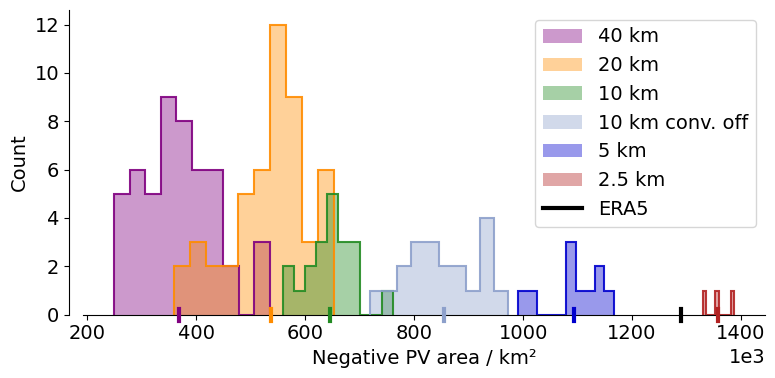

In [23]:
plt.figure(figsize=(8,4))

# Your color dictionary

labels = {
    "R02B06": "40 km",
    "R02B07": "20 km",
    "R02B08": "10 km",
    "R02B08_no_conv": "10 km conv. off",
    "R02B09": "5 km",
    "R02B10": "2.5 km"
}

colors = {
    "R02B06": "purple",
    "R02B07": "darkorange",
    "R02B08": "forestgreen",
    "R02B08_no_conv": "#8da0cb",
    "R02B09": "mediumblue",
    "R02B10": "firebrick"
}

#bins = np.linspace(2e5, 1.4e6, 30)

# Plot histogram for each resolution
for res, arr in MCS_area_pv.items():
    plt.hist(arr, alpha=0.4, label=labels[res], color=colors[res])

for res, arr in MCS_area_pv.items():
    plt.hist(arr, histtype='step', linewidth=1.5, color=colors[res], alpha = 0.9)

# Add vertical colored ticks for the mean of each distribution
for res, arr in MCS_area_pv.items():
    mean_val = np.nanmean(arr)
    plt.axvline(
        mean_val,
        ymin=-0.02, ymax=0.02,
        color=colors[res],
        linewidth=3,
        clip_on=False,
        alpha=1,
        zorder=5,
    )

plt.axvline(
    era5_area_MCS,
    ymin=-0.02, ymax=0.02,
    color='k',
    linewidth=3,
    clip_on=False,
    alpha=1,
    zorder=5,
    label='ERA5' 
)

plt.xlabel("Negative PV area / km²")
plt.ylabel("Count")
plt.title("")
plt.legend()
#plt.ylim(0.05,11)
# Adjust spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move bottom & left spines outward
ax.spines["left"].set_position(("outward", 10))
ax.ticklabel_format(axis='x', style='sci', scilimits=(3,3))
#ax.xaxis.get_offset_text().set_x(1.02)

plt.tight_layout()
plt.savefig("../Figures/June_neg_PV_area.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Position of cut-off low

### Select bests and worsts ensembles

In [24]:
names_dict = {
    "R02B06": names_r02b06,
    "R02B07": names_r02b07,
    "R02B08": names_r02b08,
    "R02B08_no_conv": names_r02b08_no_conv,
    "R02B09": names_r02b09,
    "R02B10": names_r02b10,
}

In [25]:
def extract_ic(name):
    m = re.search(r'_IC_(\d+)_', name)
    if m is None:
        raise ValueError(f"Cannot extract IC from: {name}")
    return int(m.group(1))


def build_global_acc_index(acc_dict, names_dict):
    records = []

    for res in acc_dict:
        for name, acc in zip(names_dict[res], acc_dict[res]):
            records.append({
                "resolution": res,
                "ensemble": extract_ic(name),
                "acc": float(acc),
            })

    return pd.DataFrame(records)

In [26]:
df_acc = build_global_acc_index(acc_dict, names_dict)

In [27]:
def select_global_best_worst_acc(df, n=5):
    df_sorted = df.sort_values("acc", ascending=False)

    best = list(
        zip(df_sorted.head(n)["resolution"],
            df_sorted.head(n)["ensemble"])
    )

    worst = list(
        zip(df_sorted.tail(n)["resolution"],
            df_sorted.tail(n)["ensemble"])
    )

    return best, worst

In [28]:
best_5_acc, worst_5_acc = select_global_best_worst_acc(df_acc, n=10)

In [29]:
from collections import defaultdict

def group_by_resolution(pairs):
    out = defaultdict(list)
    for res, ens in pairs:
        out[res].append(ens)
    return dict(out)

In [30]:
best_by_res  = group_by_resolution(best_5_acc)
worst_by_res = group_by_resolution(worst_5_acc)

ds_best_acc = {
    res: ds_dict[res].sel(ensemble=ens_list)
    for res, ens_list in best_by_res.items()
}

ds_worst_acc = {
    res: ds_dict[res].sel(ensemble=ens_list)
    for res, ens_list in worst_by_res.items()
}

### Plotting

In [31]:
date = "2020-06-09T15:00"
# === BEST ===
pv_best = []

for res, ds in ds_best_acc.items():
    pv_best.append(
        ds["pv"]
        .sel(time=date, plev=25000, method="nearest")
    )

pv_best_mean = xr.concat(pv_best, dim="ensemble").mean("ensemble") / 1e-6


# === WORST ===
pv_worst = []

for res, ds in ds_worst_acc.items():
    pv_worst.append(
        ds["pv"]
        .sel(time=date, plev=25000, method="nearest")
    )

pv_worst_mean = xr.concat(pv_worst, dim="ensemble").mean("ensemble") / 1e-6

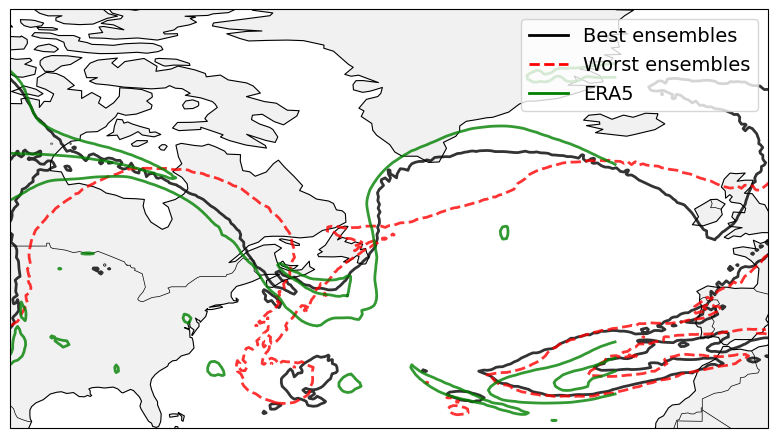

In [32]:
# --- Load ERA ---
pv_era_250 = xr.open_dataset(
    "/highres_nobackup/mrixen/simulations/June/ERA_data/ERA_PV250_3H_2020060500_2020061200"
)

era_250 = pv_era_250.sel(time=37, lev=250).PV

# --- Figure and map axis ---
fig, ax = plt.subplots(
    figsize=(8, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# --- Map features ---
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.set_extent([-100, 0, 25, 75])

# --- BEST (black solid) ---
ax.contour(
    pv_best_mean.lon,
    pv_best_mean.lat,
    pv_best_mean,
    levels=[2],
    colors="black",
    linewidths=2,
    linestyles="solid",
    alpha = 0.8,
    transform=ccrs.PlateCarree(),
)

# --- WORST (red dashed) ---
ax.contour(
    pv_worst_mean.lon,
    pv_worst_mean.lat,
    pv_worst_mean,
    levels=[2],
    colors="red",
    linewidths=2,
    linestyles="dashed",
    alpha = 0.8,
    transform=ccrs.PlateCarree(),
)

# --- ERA (green solid) ---
ax.contour(
    era_250.lon,
    era_250.lat,
    era_250,
    levels=[2],
    colors="green",
    linewidths=2,
    linestyles="solid",
    alpha = 0.8,
    transform=ccrs.PlateCarree(),
)

# --- Legend ---
legend_lines = [
    Line2D([0], [0], color="black", lw=2, linestyle="solid",
           label="Best ensembles"),
    Line2D([0], [0], color="red", lw=2, linestyle="dashed",
           label="Worst ensembles"),
    Line2D([0], [0], color="green", lw=2, linestyle="solid",
           label="ERA5"),
]

ax.legend(handles=legend_lines, loc="upper right", frameon=True)

#ax.set_title("2 PVU contour at 250 hPa, 2020-06-09 15 UTC")

plt.tight_layout()
plt.savefig("../Figures/June_position_cut_off_low.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Combined figure

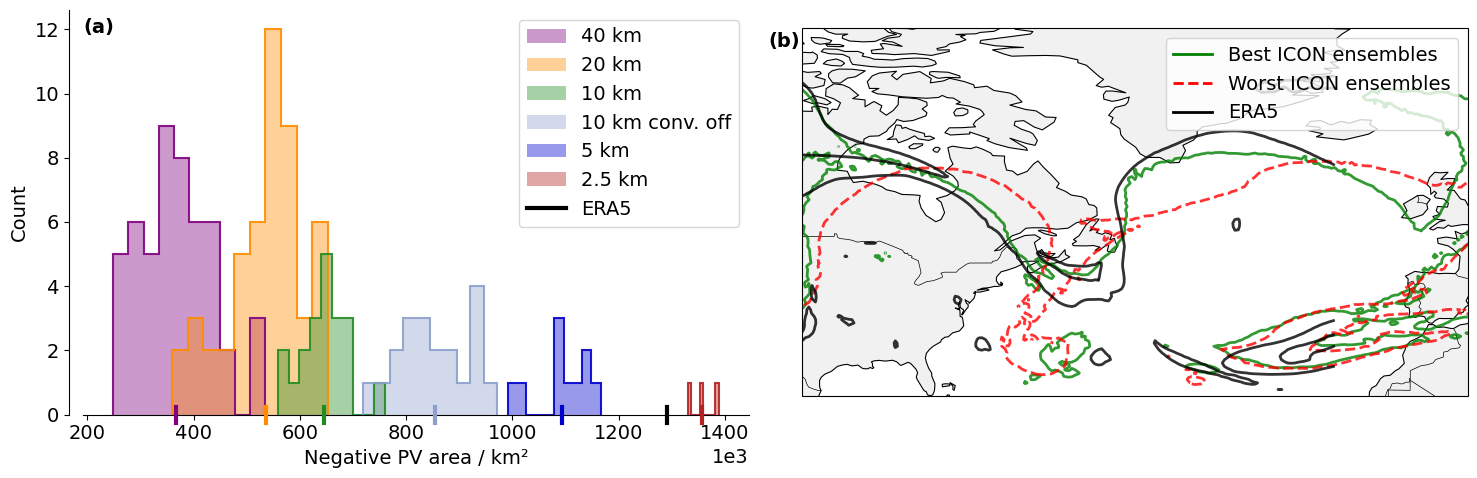

In [33]:
fig = plt.figure(figsize=(15, 5), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1])

# --- LEFT PANEL: Histogram ---
ax0 = fig.add_subplot(gs[0, 0])

# Plot histogram for each resolution
for res, arr in MCS_area_pv.items():
    ax0.hist(arr, alpha=0.4, label=labels[res], color=colors[res])

for res, arr in MCS_area_pv.items():
    ax0.hist(arr, histtype='step', linewidth=1.5, color=colors[res], alpha=0.9)

# Vertical lines for means
for res, arr in MCS_area_pv.items():
    mean_val = np.nanmean(arr)
    ax0.axvline(mean_val, ymin=-0.02, ymax=0.02,
                color=colors[res], linewidth=3, clip_on=False, alpha=1, zorder=5)

# ERA5 vertical line
ax0.axvline(era5_area_MCS, ymin=-0.02, ymax=0.02,
            color='k', linewidth=3, clip_on=False, alpha=1, zorder=5, label='ERA5')

ax0.set_xlabel("Negative PV area / km²")
ax0.set_ylabel("Count")
ax0.spines["top"].set_visible(False)
ax0.spines["right"].set_visible(False)
ax0.spines["left"].set_position(("outward", 10))
ax0.ticklabel_format(axis='x', style='sci', scilimits=(3,3))
ax0.legend()
#ax0.set_title("Distribution of negative PV area")
ax0.text(0.0, 0.98, "(a)", transform=ax0.transAxes,
         fontsize=14, fontweight="bold", va="top", ha="left")

# --- RIGHT PANEL: PV contour map ---
ax1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())

# Map features
ax1.coastlines(linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
ax1.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax1.add_feature(cfeature.OCEAN, facecolor="white")
ax1.set_extent([-100, 0, 25, 75])

# Contours
ax1.contour(pv_best_mean.lon, pv_best_mean.lat, pv_best_mean,
            levels=[2], colors="green", linewidths=2, linestyles="solid",
            alpha=0.8, transform=ccrs.PlateCarree())

ax1.contour(pv_worst_mean.lon, pv_worst_mean.lat, pv_worst_mean,
            levels=[2], colors="red", linewidths=2, linestyles="dashed",
            alpha=0.8, transform=ccrs.PlateCarree())

ax1.contour(era_250.lon, era_250.lat, era_250,
            levels=[2], colors="black", linewidths=2, linestyles="solid",
            alpha=0.8, transform=ccrs.PlateCarree())

ax1.text(-0.05, 0.99, "(b)", transform=ax1.transAxes,
         fontsize=14, fontweight="bold", va="top", ha="left")

# Legend
legend_lines = [
    Line2D([0], [0], color="green", lw=2, linestyle="solid", label="Best ICON ensembles"),
    Line2D([0], [0], color="red", lw=2, linestyle="dashed", label="Worst ICON ensembles"),
    Line2D([0], [0], color="black", lw=2, linestyle="solid", label="ERA5"),
]
ax1.legend(handles=legend_lines, loc="upper right", frameon=True)
#ax1.set_title("2 PVU contour at 250 hPa")

# --- Final adjustments ---
plt.tight_layout()
plt.savefig("../Figures/June_combined_MCS.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Overview plots

In [25]:
time_sel = '2020-06-11T00:00'
# ------------------------------------------------------
# Select data
# ------------------------------------------------------
z500_ifs = ds_IFS.z.sel(time=time_sel, level=500) / 9.81
z500_era = ds_era_geo.Z.sel(time=time_sel, plev=50000) / 9.81
z500_icon_good = ds_R02B09.sel(time=time_sel).sel(ensemble=4).geopot.sel(plev=50000) / 9.81
z500_icon_bad = ds_R02B09.sel(time=time_sel).sel(ensemble=2).geopot.sel(plev=50000) / 9.81

In [26]:
z500_diff = z500_era - z500_ifs

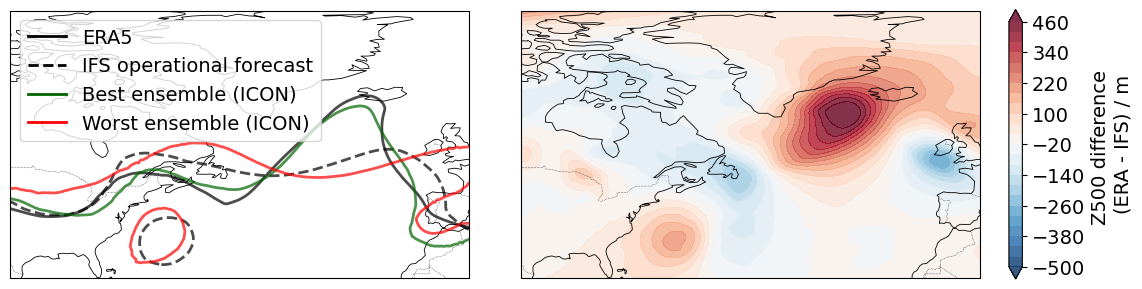

In [27]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

# ------------------------------------------------------
# Two-panel figure with equal panel sizes
# ------------------------------------------------------
fig = plt.figure(figsize=(14, 5))

# Create a gridspec with 2 columns, leaving room for colorbar on the right
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.25], wspace=0.1)

# Common map extent
extent = [-100, 0, 25, 80]
contour_level = 5780

# ---------------- Left panel: original contours ----------------
ax0 = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
ax0.set_extent(extent)
ax0.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax0.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.4)

# ERA5 5800 m contour (black solid)
ax0.contour(z500_era.lon, z500_era.lat, z500_era,
            levels=[contour_level], colors="black", linewidths=2.0, alpha=0.7)
# IFS 5800 m contour (black dashed)
ax0.contour(z500_ifs.lon, z500_ifs.lat, z500_ifs,
            levels=[contour_level], colors="black", linestyles="--", linewidths=2.0, alpha=0.7)
# ICON good/bad ensembles
ax0.contour(z500_icon_good.lon, z500_icon_good.lat, z500_icon_good,
            levels=[contour_level], colors="darkgreen", linewidths=2.0, alpha=0.7)
ax0.contour(z500_icon_bad.lon, z500_icon_bad.lat, z500_icon_bad,
            levels=[contour_level], colors="red", linewidths=2.0, alpha=0.7)

legend_handles = [
    Line2D([], [], color="black", linewidth=2.0, linestyle="-", label="ERA5"),
    Line2D([], [], color="black", linewidth=2.0, linestyle="--", label="IFS operational forecast"),
    Line2D([], [], color="darkgreen", linewidth=2.0, linestyle="-", label="Best ensemble (ICON)"),
    Line2D([], [], color="red", linewidth=2.0, linestyle="-", label="Worst ensemble (ICON)"),
]
ax0.legend(handles=legend_handles, loc="upper left", frameon=True)

# ---------------- Right panel: ERA5 - IFS difference ----------------
ax1 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
ax1.set_extent(extent)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax1.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.4)

diff_levels = np.arange(-500, 500, 40)
cf = ax1.contourf(z500_diff.lon, z500_diff.lat, z500_diff,
                  levels=diff_levels, cmap="RdBu_r", extend="both", alpha=0.8)

# Place colorbar outside the right of ax1
cbar = fig.colorbar(cf, ax=ax1, orientation="vertical", shrink=0.7, pad=0.05)
cbar.set_label("Z500 difference \n(ERA - IFS) / m", fontsize=14)

plt.tight_layout()
plt.savefig("../Figures/June_Z500_overview.pdf", dpi=300, bbox_inches="tight")
plt.show()